<a href="https://colab.research.google.com/github/OliverC-ops/Final-python-code/blob/main/Python_assignment_code_Oliver_C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
interest = loan['interest_rate']

summary = pd.DataFrame({
    'Statistic': ['Mean', 'Median', 'Standard Deviation', 'IQR'],
    'Value': [
        interest.mean(),
        interest.median(),
        interest.std(),
        interest.quantile(0.75) - interest.quantile(0.25)
    ]
})

print(summary)

            Statistic      Value
0                Mean  11.567200
1              Median   9.930000
2  Standard Deviation   5.052115
3                 IQR   5.755000


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt



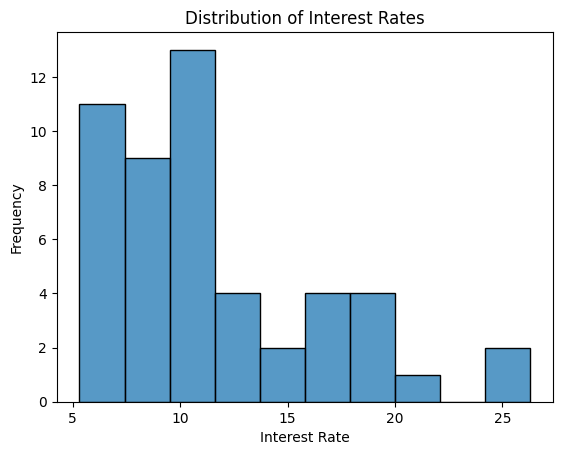

In [ ]:
sns.histplot(loan['interest_rate'], bins=10)
plt.title('Distribution of Interest Rates')
plt.xlabel('Interest Rate')
plt.ylabel('Frequency')
plt.show()

homeownership
mortgage    26
rent        21
own          3
Name: count, dtype: int64


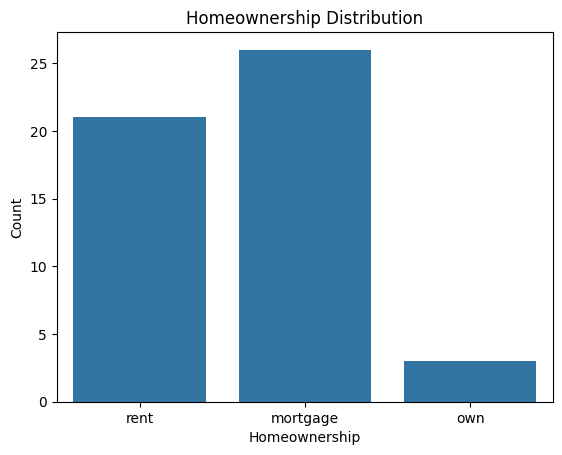

In [ ]:
freq = loan['homeownership'].value_counts()
print(freq)

sns.countplot(data=loan, x='homeownership')
plt.title('Homeownership Distribution')
plt.xlabel('Homeownership')
plt.ylabel('Count')
plt.show()


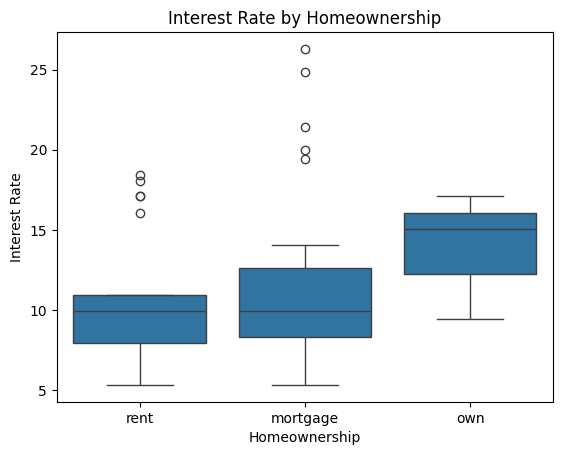

In [ ]:
sns.boxplot(data=loan, x='homeownership', y='interest_rate')
plt.title('Interest Rate by Homeownership')
plt.xlabel('Homeownership')
plt.ylabel('Interest Rate')
plt.show()

In [ ]:
import pandas as pd

nc = pd.read_csv('/ncbirths.csv')

nc['premature'] = (nc['weeks'] < 37).astype(int)

ct = pd.crosstab(nc['habit'], nc['premature'])
print(ct)

props = ct.div(ct.sum(axis=1), axis=0)
print(props)

premature    0    1
habit              
nonsmoker  740  133
smoker     107   19
premature         0         1
habit                        
nonsmoker  0.847652  0.152348
smoker     0.849206  0.150794


In [ ]:
import numpy as np

p1 = props.loc['smoker', 1]
p2 = props.loc['nonsmoker', 1]

n1 = ct.loc['smoker'].sum()
n2 = ct.loc['nonsmoker'].sum()

se = np.sqrt((p1*(1-p1)/n1) + (p2*(1-p2)/n2))

lower = (p1-p2) - 1.96*se
upper = (p1-p2) + 1.96*se

print(lower, upper)

-0.06843147436259368 0.06532232692354929


In [ ]:
from scipy.stats import norm

x1 = ct.loc['smoker', 1]
x2 = ct.loc['nonsmoker', 1]

p_pool = (x1 + x2) / (n1 + n2)

se_pool = np.sqrt(p_pool * (1-p_pool) * ((1/n1) + (1/n2)))

z = (p1 - p2) / se_pool

p_value = 2 * (1 - norm.cdf(abs(z)))

print(z, p_value)

-0.04541747240132055 0.9637745543952176


In [ ]:
summary = nc.groupby('habit')['weight'].agg(['mean', 'std'])
print(summary)

               mean       std
habit                        
nonsmoker  7.144273  1.518681
smoker     6.828730  1.386180


In [ ]:
from scipy.stats import ttest_ind

smoker = nc[nc['habit'] == 'smoker']['weight']
nonsmoker = nc[nc['habit'] == 'nonsmoker']['weight']

result = ttest_ind(smoker, nonsmoker, equal_var=False)

print(result)

TtestResult(statistic=np.float64(-2.3590109449335013), pvalue=np.float64(0.01945055644373227), df=np.float64(171.3246566624258))


In [ ]:
import pandas as pd
import numpy as np

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving ncbirths.csv to ncbirths.csv


In [ ]:
nc = pd.read_csv('ncbirths.csv')

In [ ]:
summary = nc.groupby('habit')['weight'].agg(['mean', 'std'])
print(summary)

               mean       std
habit                        
nonsmoker  7.144273  1.518681
smoker     6.828730  1.386180


In [ ]:
from google.colab import files
uploaded = files.upload()


Saving mariokart.csv to mariokart.csv


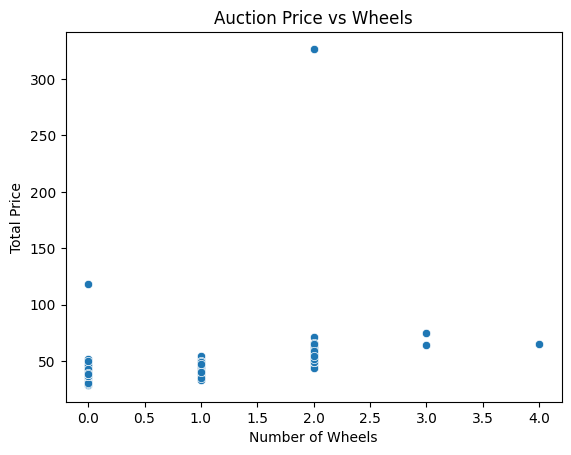

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

mk = pd.read_csv('mariokart.csv')

sns.scatterplot(data=mk, x='wheels', y='total_pr')
plt.title('Auction Price vs Wheels')
plt.xlabel('Number of Wheels')
plt.ylabel('Total Price')
plt.show()

In [1]:
pip install stargazer

In [4]:
import statsmodels.formula.api as smf

In [32]:
mk = pd.read_csv("mariokart.csv")

In [ ]:
import statsmodels.formula.api as smf

model1 = smf.ols('total_pr ~ wheels', data=mk).fit()
print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:               total_pr   R-squared:                       0.109
Model:                            OLS   Adj. R-squared:                  0.103
Method:                 Least Squares   F-statistic:                     17.23
Date:                Sun, 17 May 2026   Prob (F-statistic):           5.70e-05
Time:                        14:51:11   Log-Likelihood:                -658.35
No. Observations:                 143   AIC:                             1321.
Df Residuals:                     141   BIC:                             1327.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     38.4052      3.433     11.188      0.0

In [22]:
from google.colab import files
uploaded = files.upload()

Saving mariokart.csv to mariokart (2).csv


In [35]:
model1 = smf.ols('total_pr ~ wheels', data=mk).fit()

In [36]:
table=Stargazer([model1])
table

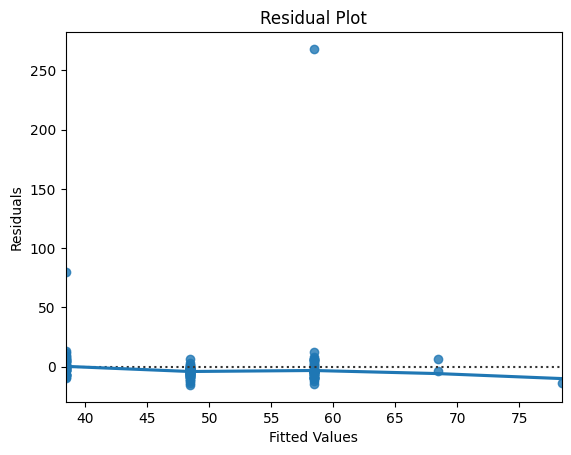

In [ ]:
sns.residplot(x=model1.fittedvalues, y=model1.resid, lowess=True)
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()

In [ ]:
model2 = smf.ols(
    'total_pr ~ C(cond) + C(stock_photo) + duration + wheels',
    data=mk
).fit()

print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:               total_pr   R-squared:                       0.123
Model:                            OLS   Adj. R-squared:                  0.098
Method:                 Least Squares   F-statistic:                     4.860
Date:                Sun, 17 May 2026   Prob (F-statistic):            0.00107
Time:                        16:09:50   Log-Likelihood:                -657.17
No. Observations:                 143   AIC:                             1324.
Df Residuals:                     138   BIC:                             1339.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                43.52

In [38]:
model2 = smf.ols(
    'total_pr ~ C(cond) + C(stock_photo) + duration + wheels',
    data=mk
).fit()

In [39]:
table=Stargazer([model2])
table

In [ ]:
m1 = smf.ols('total_pr ~ wheels', data=mk).fit()
m2 = smf.ols('total_pr ~ wheels + C(stock_photo)', data=mk).fit()
m3 = smf.ols('total_pr ~ C(cond) + C(stock_photo) + duration + wheels', data=mk).fit()

print(m1.rsquared_adj)
print(m2.rsquared_adj)
print(m3.rsquared_adj)

0.10256934188969413
0.1089478202871772
0.09807529266808301


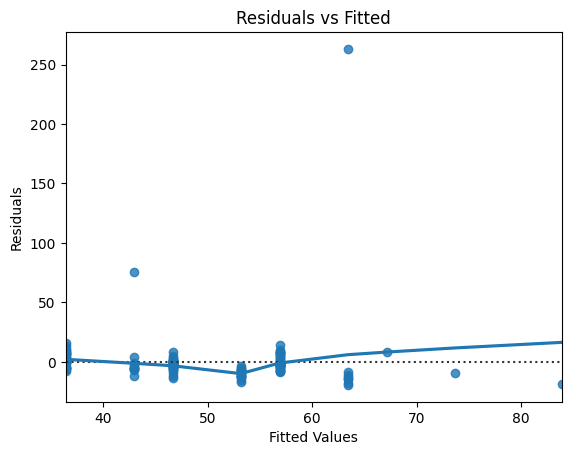

In [ ]:
best_model = smf.ols('total_pr ~ wheels + C(stock_photo)', data=mk).fit()

sns.residplot(x=best_model.fittedvalues, y=best_model.resid, lowess=True)
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs Fitted')
plt.show()

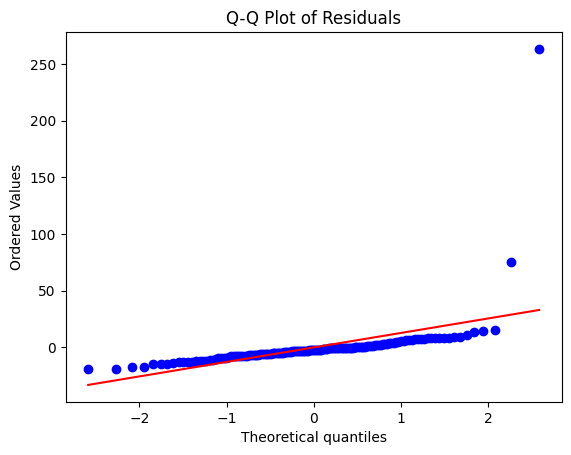

In [ ]:
from scipy import stats

stats.probplot(best_model.resid, dist='norm', plot=plt)
plt.title('Q-Q Plot of Residuals')
plt.show()